**Template-based vs Optical Flow (Lucas-Kanade)**


In [1]:
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Image, HTML
from dataclasses import dataclass, field
from typing import Optional, List, Tuple

In [2]:
VIDEO_PATH = "Test Video.mp4"
INITIAL_ROI = (300, 200, 80, 50)
INTERACTIVE_ROI = True
MAX_FRAMES = 200
OUTPUT_TEMPLATE   = "output_template.mp4"
OUTPUT_OPTFLOW    = "output_optflow.mp4"
OUTPUT_SIDEBYSIDE = "output_comparison.mp4"

print(f'   Video input  : {VIDEO_PATH}')
print(f'   ROI awal     : {INITIAL_ROI}')
print(f'   Max frame    : {MAX_FRAMES}')

   Video input  : Test Video.mp4
   ROI awal     : (300, 200, 80, 50)
   Max frame    : 200


In [3]:
def select_roi(video_path: str, interactive: bool, default_roi: tuple) -> tuple:
    cap = cv2.VideoCapture(video_path)    
    ret, frame = cap.read()                
    cap.release()

    if interactive:
        print('Klik-drag untuk pilih area kendaraan, lalu tekan ENTER')
        roi = cv2.selectROI('Pilih Kendaraan (ENTER = konfirmasi)', frame)
        cv2.destroyAllWindows()
        if roi == (0,0,0,0):
            print('ROI tidak dipilih, pakai default.')
            return default_roi
        return roi
    else:
        preview = frame.copy()
        x,y,w,h = default_roi
        cv2.rectangle(preview, (x,y), (x+w,y+h), (0,255,0), 2)  # Kotak hijau
        cv2.putText(preview, 'ROI', (x, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

        _, buf = cv2.imencode('.jpg', preview)
        display(Image(data=buf.tobytes()))
        return default_roi


roi = select_roi(VIDEO_PATH, INTERACTIVE_ROI, INITIAL_ROI)
print(f'\nROI dipilih: x={roi[0]}, y={roi[1]}, w={roi[2]}, h={roi[3]}')

Klik-drag untuk pilih area kendaraan, lalu tekan ENTER

ROI dipilih: x=324, y=299, w=45, h=59


In [4]:
@dataclass
class TrackingResult:
    method_name: str
    positions:     List[Tuple] = field(default_factory=list)  
    boxes:         List[Tuple] = field(default_factory=list)  
    fps_values:    List[float] = field(default_factory=list)  
    success_flags: List[bool]  = field(default_factory=list)  

    def add(self, pos, box, fps, success):
        self.positions.append(pos)
        self.boxes.append(box)
        self.fps_values.append(fps)
        self.success_flags.append(success)

    @property
    def avg_fps(self):      return np.mean(self.fps_values) if self.fps_values else 0
    @property
    def success_rate(self): return sum(self.success_flags)/len(self.success_flags)*100 if self.success_flags else 0

print('Dataclass TrackingResult siap')

Dataclass TrackingResult siap


In [5]:
def run_template_tracking(video_path, initial_roi, max_frames=None,
                           output_path=None) -> TrackingResult:
    """
    Template Matching: geser potongan gambar (template) ke seluruh frame baru,
    cari posisi paling mirip → itu posisi objek berikutnya.
    """
    result = TrackingResult(method_name='Template Matching')
    cap = cv2.VideoCapture(video_path)

    fps_video = cap.get(cv2.CAP_PROP_FPS) or 30.0   
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))        
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))        

    writer = None
    if output_path:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')        
        writer = cv2.VideoWriter(output_path, fourcc, fps_video, (W, H))

    ret, first_frame = cap.read()
    x, y, w, h = initial_roi
    template = first_frame[y:y+h, x:x+w].copy()    # Template = potongan gambar awal
    current_box = initial_roi
    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret or (max_frames and frame_count >= max_frames):
            break

        t0 = time.time()

        gray_frame    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray_template = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

        margin = 150
        cx, cy = current_box[0], current_box[1]
        sx1, sy1 = max(0, cx-margin),           max(0, cy-margin)
        sx2, sy2 = min(W, cx+w+margin),         min(H, cy+h+margin)
        search   = gray_frame[sy1:sy2, sx1:sx2]

        success, matched_box = False, current_box

        if search.shape[0] > gray_template.shape[0] and \
           search.shape[1] > gray_template.shape[1]:

            result_map = cv2.matchTemplate(search, gray_template,
                                           cv2.TM_CCOEFF_NORMED)
            _, max_val, _, max_loc = cv2.minMaxLoc(result_map)

            if max_val > 0.4:   
                new_x = sx1 + max_loc[0]   
                new_y = sy1 + max_loc[1]
                matched_box = (new_x, new_y, w, h)
                current_box = matched_box
                success = True

                if frame_count % 10 == 0:
                    ny1,ny2 = max(0,new_y), min(H,new_y+h)
                    nx1,nx2 = max(0,new_x), min(W,new_x+w)
                    template = frame[ny1:ny2, nx1:nx2].copy()

        fps = 1.0 / (time.time()-t0 or 1e-9)
        pos = (matched_box[0]+w//2, matched_box[1]+h//2)   
        result.add(pos, matched_box, fps, success)

        out_frame = frame.copy()
        bx,by,bw,bh = [int(v) for v in matched_box]
        color = (0,220,0) if success else (0,0,220)        
        cv2.rectangle(out_frame, (bx,by), (bx+bw,by+bh), color, 2)
        label = f'Template | {fps:.0f} FPS'
        cv2.rectangle(out_frame, (bx, by-22), (bx+len(label)*9, by), color, -1)
        cv2.putText(out_frame, label, (bx+3,by-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
        cv2.putText(out_frame, f'Frame: {frame_count}',
                    (10,28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,0), 2)
        cv2.putText(out_frame, f'Success: {result.success_rate:.0f}%',
                    (10,55), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,0), 2)

        if writer:
            writer.write(out_frame)

        frame_count += 1
        if frame_count % 50 == 0:
            print(f'   Frame {frame_count}/{max_frames} | '
                  f'avg FPS: {result.avg_fps:.1f} | '
                  f'success: {result.success_rate:.0f}%')

    cap.release()
    if writer:
        writer.release()
        print(f'\n💾 Video disimpan: {output_path}')

    print(f'Template selesai | {frame_count} frame | '
          f'avg FPS: {result.avg_fps:.1f} | '
          f'success rate: {result.success_rate:.1f}%')
    return result


# Jalankan Template Tracking
template_result = run_template_tracking(
    VIDEO_PATH, roi,
    max_frames=MAX_FRAMES,
    output_path=OUTPUT_TEMPLATE
)

   Frame 50/200 | avg FPS: 250.3 | success: 100%
   Frame 100/200 | avg FPS: 253.0 | success: 100%
   Frame 150/200 | avg FPS: 254.2 | success: 100%
   Frame 200/200 | avg FPS: 257.8 | success: 100%

💾 Video disimpan: output_template.mp4
Template selesai | 200 frame | avg FPS: 257.8 | success rate: 100.0%


In [6]:
def iou(boxA, boxB):
    """
    Hitung Intersection over Union antara dua box.
    Nilai 0 = tidak overlap sama sekali, 1 = identik.
    Dipakai untuk deteksi drift: kalau box baru terlalu jauh
    dari box lama, berarti titik fitur sudah melacak objek lain.
    """
    ax, ay, aw, ah = boxA
    bx, by, bw, bh = boxB
    # Koordinat irisan (area yang tumpang tindih)
    ix1 = max(ax, bx)
    iy1 = max(ay, by)
    ix2 = min(ax+aw, bx+bw)
    iy2 = min(ay+ah, by+bh)
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)   # Luas irisan
    union = aw*ah + bw*bh - inter                 # Luas gabungan
    return inter / union if union > 0 else 0


def run_optical_flow_tracking(video_path, initial_roi, max_frames=None,
                               output_path=None) -> TrackingResult:
    """
    Lucas-Kanade Optical Flow dengan perlindungan anti-drift:
    - Setiap frame cek apakah pergeseran masuk akal (IoU + max shift)
    - Kalau drift terdeteksi, tolak hasil dan paksa refresh titik fitur
    - Verifikasi ulang pakai matchTemplate setiap 15 frame
    """
    result = TrackingResult(method_name='Optical Flow (Lucas-Kanade)')
    cap = cv2.VideoCapture(video_path)

    fps_video = cap.get(cv2.CAP_PROP_FPS) or 30.0
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    writer = None
    if output_path:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        writer = cv2.VideoWriter(output_path, fourcc, fps_video, (W, H))

    ret, first_frame = cap.read()
    x, y, w, h = initial_roi

    prev_gray = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)

    template = first_frame[y:y+h, x:x+w].copy()

    mask = np.zeros_like(prev_gray)
    mask[y:y+h, x:x+w] = 255

    feature_params = dict(maxCorners=50, qualityLevel=0.1,
                          minDistance=5, blockSize=7)
    lk_params = dict(winSize=(15,15), maxLevel=3,
                     criteria=(cv2.TERM_CRITERIA_EPS|cv2.TERM_CRITERIA_COUNT,
                                20, 0.03))

    prev_pts = cv2.goodFeaturesToTrack(prev_gray, mask=mask, **feature_params)

    current_box = initial_roi
    last_valid_box = initial_roi    
    frame_count = 0
    trail = []

    MAX_SHIFT_PER_FRAME = 40

    while True:
        ret, frame = cap.read()
        if not ret or (max_frames and frame_count >= max_frames):
            break

        t0 = time.time()
        curr_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        out_frame = frame.copy()

        success = False
        matched_box = current_box

        if prev_pts is not None and len(prev_pts) > 0:

            next_pts, status, _ = cv2.calcOpticalFlowPyrLK(
                prev_gray, curr_gray, prev_pts, None, **lk_params)

            if next_pts is not None:
                good_prev = prev_pts[status==1]
                good_next = next_pts[status==1]

                if len(good_next) > 3:
                    dx = np.mean(good_next[:,0] - good_prev[:,0])
                    dy = np.mean(good_next[:,1] - good_prev[:,1])
                    shift = np.sqrt(dx**2 + dy**2)   # Jarak geser total (piksel)

                    bx = int(np.clip(current_box[0]+dx, 0, W-w))
                    by = int(np.clip(current_box[1]+dy, 0, H-h))
                    candidate_box = (bx, by, w, h)

                    overlap = iou(current_box, candidate_box)

                    if overlap > 0.3 and shift < MAX_SHIFT_PER_FRAME:
                        matched_box = candidate_box
                        current_box = matched_box
                        last_valid_box = current_box   # Catat sebagai posisi valid
                        prev_pts = good_next.reshape(-1,1,2)
                        success = True
                    else:
                        success = False
                        current_box = last_valid_box   # Kembalikan ke posisi terakhir OK
                        matched_box = last_valid_box
                        prev_pts = None                # Paksa refresh titik fitur

                else:
                    success = False
                    prev_pts = None    # Paksa refresh
            else:
                success = False
                prev_pts = None
        else:
            success = False

        if frame_count % 15 == 0 and success:
            gray_frame    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            gray_template = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

            margin = 60
            cx, cy = current_box[0], current_box[1]
            sx1 = max(0, cx-margin);  sy1 = max(0, cy-margin)
            sx2 = min(W, cx+w+margin); sy2 = min(H, cy+h+margin)
            search = gray_frame[sy1:sy2, sx1:sx2]

            if search.shape[0] > gray_template.shape[0] and \
               search.shape[1] > gray_template.shape[1]:
                res_map = cv2.matchTemplate(search, gray_template,
                                            cv2.TM_CCOEFF_NORMED)
                _, max_val, _, max_loc = cv2.minMaxLoc(res_map)

                if max_val > 0.35:
                    vx = sx1 + max_loc[0]
                    vy = sy1 + max_loc[1]
                    current_box = (vx, vy, w, h)
                    matched_box = current_box
                    last_valid_box = current_box
                    template = frame[max(0,vy):min(H,vy+h),
                                     max(0,vx):min(W,vx+w)].copy()
                else:
                    success = False

        if frame_count % 30 == 0 or prev_pts is None or \
           (prev_pts is not None and len(prev_pts) < 5):
            ref_mask = np.zeros_like(curr_gray)
            bx2,by2 = current_box[0], current_box[1]
            ref_mask[max(0,by2):min(H,by2+h),
                     max(0,bx2):min(W,bx2+w)] = 255
            new_pts = cv2.goodFeaturesToTrack(curr_gray, mask=ref_mask,
                                              **feature_params)
            if new_pts is not None:
                prev_pts = new_pts

        prev_gray = curr_gray.copy()

        mbx,mby,mbw,mbh = [int(v) for v in matched_box]

        if prev_pts is not None and success:
            for pt in prev_pts:
                px,py = int(pt[0][0]), int(pt[0][1])
                cv2.circle(out_frame, (px,py), 3, (0,200,255), -1)

        center = (mbx+w//2, mby+h//2)
        trail.append(center)
        if len(trail) > 40:
            trail.pop(0)
        for i in range(1, len(trail)):
            alpha = i / len(trail)
            cv2.line(out_frame, trail[i-1], trail[i],
                     (int(255*alpha), int(100*alpha), 0), 2)

        # Bounding box: hijau=OK, merah=drift/gagal
        color = (0,200,255) if success else (0,0,220)
        cv2.rectangle(out_frame, (mbx,mby), (mbx+mbw,mby+mbh), color, 2)

        fps = 1.0 / (time.time()-t0 or 1e-9)
        label = f'OPTICAL FLOW | {fps:.0f} FPS'
        cv2.rectangle(out_frame, (mbx,mby-22),(mbx+len(label)*9,mby), color,-1)
        cv2.putText(out_frame, label, (mbx+3,mby-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
        cv2.putText(out_frame, f'Frame: {frame_count}',
                    (10,28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,0), 2)
        cv2.putText(out_frame, f'Success: {result.success_rate:.0f}%',
                    (10,55), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,0), 2)

        if not success:
            cv2.putText(out_frame, '⚠ DRIFT / GAGAL',
                        (10,85), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,220), 2)

        pos = (matched_box[0]+w//2, matched_box[1]+h//2)
        result.add(pos, matched_box, fps, success)

        if writer:
            writer.write(out_frame)

        frame_count += 1
        if frame_count % 50 == 0:
            print(f'   Frame {frame_count}/{max_frames} | '
                  f'avg FPS: {result.avg_fps:.1f} | '
                  f'success: {result.success_rate:.0f}%')

    cap.release()
    if writer:
        writer.release()
        print(f'\n💾 Video disimpan: {output_path}')

    print(f'Optical Flow selesai | {frame_count} frame | '
          f'avg FPS: {result.avg_fps:.1f} | '
          f'success rate: {result.success_rate:.1f}%')
    return result


# Jalankan
optical_result = run_optical_flow_tracking(
    VIDEO_PATH, roi,
    max_frames=MAX_FRAMES,
    output_path=OUTPUT_OPTFLOW
)

   Frame 50/200 | avg FPS: 323.4 | success: 100%
   Frame 100/200 | avg FPS: 310.6 | success: 100%
   Frame 150/200 | avg FPS: 316.0 | success: 100%
   Frame 200/200 | avg FPS: 335.8 | success: 100%

💾 Video disimpan: output_optflow.mp4
Optical Flow selesai | 200 frame | avg FPS: 335.8 | success rate: 100.0%


In [7]:
def export_side_by_side(video_path, template_res: TrackingResult,
                         optical_res: TrackingResult,
                         initial_roi, output_path, max_frames=None):
    """
    Buat video perbandingan: Template (kiri) vs Optical Flow (kanan)
    dalam satu layar berdampingan.
    """
    cap = cv2.VideoCapture(video_path)
    fps_video = cap.get(cv2.CAP_PROP_FPS) or 30.0
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Output video lebarnya 2x (kiri + kanan)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(output_path, fourcc, fps_video, (W*2, H))

    x,y,w,h = initial_roi
    frame_count = 0
    n_tmpl = len(template_res.boxes)
    n_opt  = len(optical_res.boxes)
    limit  = min(n_tmpl, n_opt, max_frames or 999999)

    while frame_count < limit:
        ret, frame = cap.read()
        if not ret:
            break

        # Buat dua salinan frame: satu untuk Template, satu untuk Optical Flow
        left  = frame.copy()   # Panel kiri  = Template
        right = frame.copy()   # Panel kanan = Optical Flow

        # Gambar hasil Template di panel kiri
        tb = template_res.boxes[frame_count]
        ts = template_res.success_flags[frame_count]
        tf = template_res.fps_values[frame_count]
        bx,by,bw,bh = [int(v) for v in tb]
        tc = (0,220,0) if ts else (0,0,220)
        cv2.rectangle(left, (bx,by),(bx+bw,by+bh), tc, 2)
        cv2.putText(left, f'TEMPLATE | {tf:.0f} FPS',
                    (10,30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,220,0), 2)
        cv2.putText(left, f'Success: {template_res.success_rate:.0f}%',
                    (10,60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,0), 2)
        # Garis divider di tepi kanan panel kiri
        cv2.line(left, (W-3,0),(W-3,H), (255,255,255), 3)

        # Gambar hasil Optical Flow di panel kanan
        ob = optical_res.boxes[frame_count]
        os_ = optical_res.success_flags[frame_count]
        of_ = optical_res.fps_values[frame_count]
        bx,by,bw,bh = [int(v) for v in ob]
        oc = (0,165,255) if os_ else (0,0,220)
        cv2.rectangle(right, (bx,by),(bx+bw,by+bh), oc, 2)
        cv2.putText(right, f'OPTICAL FLOW | {of_:.0f} FPS',
                    (10,30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,165,255), 2)
        cv2.putText(right, f'Success: {optical_res.success_rate:.0f}%',
                    (10,60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,0), 2)

        # Nomor frame di tengah bawah
        combined = np.hstack([left, right])  # Gabung kiri dan kanan secara horizontal
        cv2.putText(combined, f'Frame {frame_count}',
                    (W-50, H-15), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200,200,200), 1)

        writer.write(combined)
        frame_count += 1

    cap.release()
    writer.release()
    print(f'\n💾 Video side-by-side disimpan: {output_path}')
    print(f'   Ukuran frame: {W*2} x {H} piksel')


# Jalankan export video perbandingan
export_side_by_side(
    VIDEO_PATH, template_result, optical_result,
    roi, OUTPUT_SIDEBYSIDE, max_frames=MAX_FRAMES
)


💾 Video side-by-side disimpan: output_comparison.mp4
   Ukuran frame: 1696 x 480 piksel


💾 Laporan disimpan: tracking_report.png


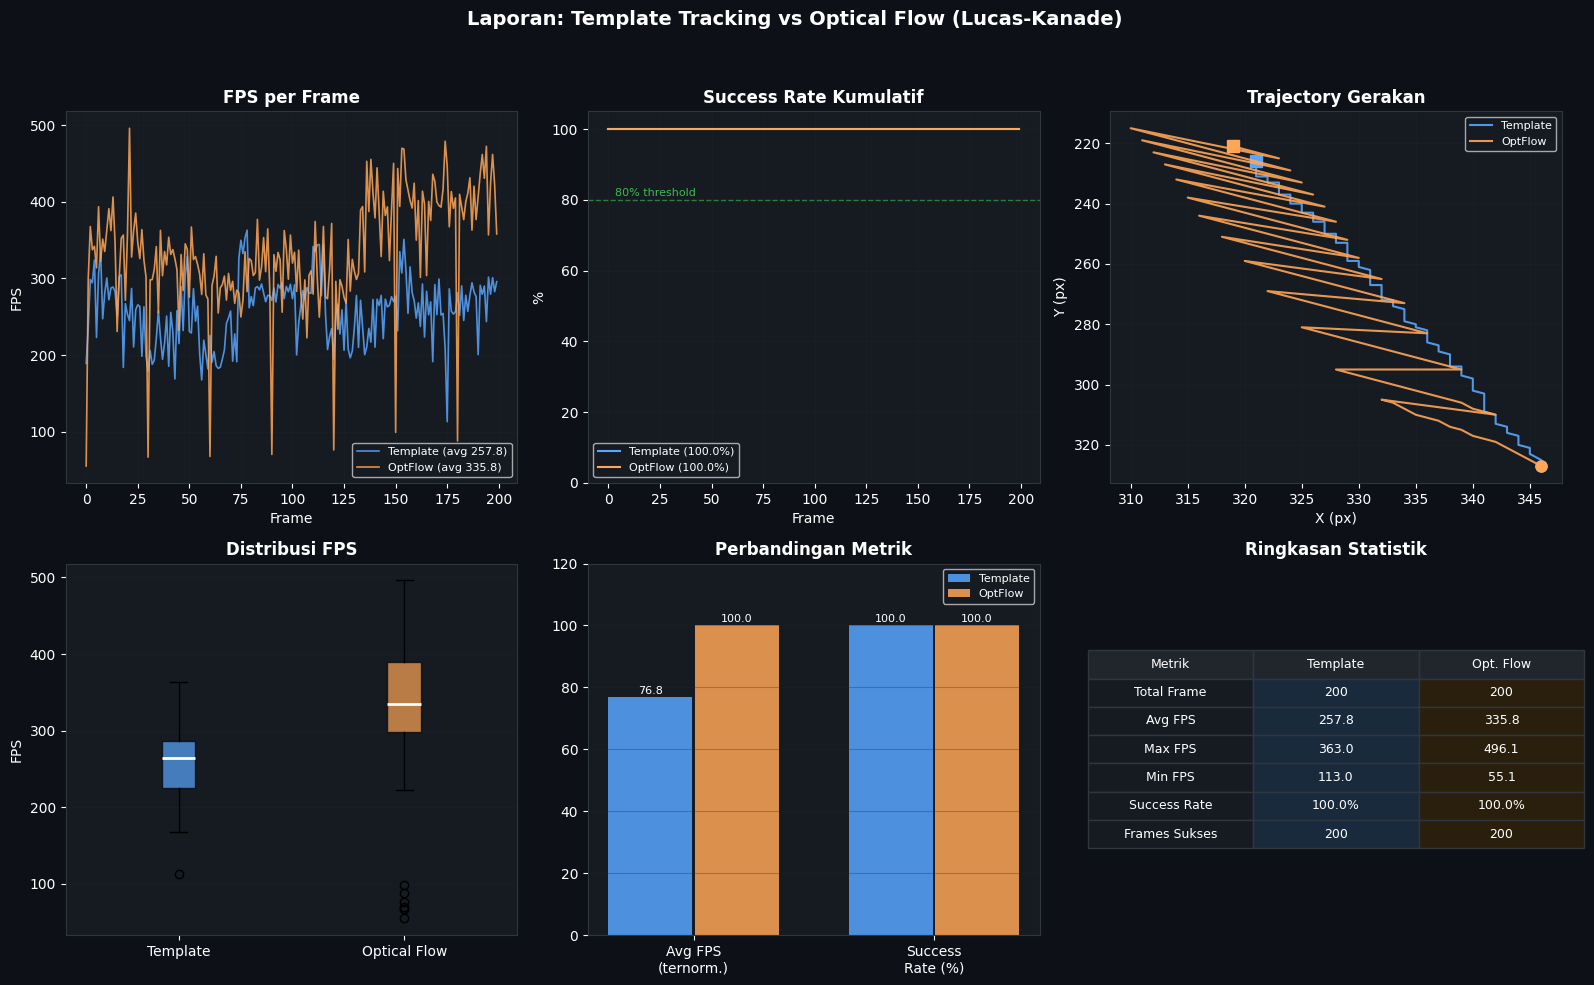

In [8]:
def plot_accuracy_report(t_res: TrackingResult, o_res: TrackingResult):
    """Visualisasi perbandingan lengkap kedua metode dalam satu figure."""

    fig = plt.figure(figsize=(16, 10), facecolor='#0d1117')
    plt.rcParams.update({'text.color':'white','axes.facecolor':'#161b22',
                         'axes.edgecolor':'#30363d','axes.labelcolor':'white',
                         'xtick.color':'white','ytick.color':'white',
                         'grid.color':'#21262d'})
    CT = '#58a6ff'   # Warna Template  (biru)
    CO = '#ffa657'   # Warna OptFlow   (oranye)

    nt, no = len(t_res.fps_values), len(o_res.fps_values)
    ft, fo = range(nt), range(no)

    # 1. FPS per frame
    ax1 = fig.add_subplot(2,3,1)
    ax1.plot(ft, t_res.fps_values, color=CT, lw=1.2, alpha=0.85,
             label=f'Template (avg {t_res.avg_fps:.1f})')
    ax1.plot(fo, o_res.fps_values, color=CO, lw=1.2, alpha=0.85,
             label=f'OptFlow (avg {o_res.avg_fps:.1f})')
    ax1.set_title('FPS per Frame', color='white', fontweight='bold')
    ax1.set_xlabel('Frame'); ax1.set_ylabel('FPS')
    ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

    # 2. Success rate bergulir (window 30 frame)
    ax2 = fig.add_subplot(2,3,2)
    def rolling(flags, w=30):
        return [sum(flags[max(0,i-w):i+1])/len(flags[max(0,i-w):i+1])*100
                for i in range(len(flags))]
    ax2.plot(ft, rolling(t_res.success_flags), color=CT, lw=1.5,
             label=f'Template ({t_res.success_rate:.1f}%)')
    ax2.plot(fo, rolling(o_res.success_flags), color=CO, lw=1.5,
             label=f'OptFlow ({o_res.success_rate:.1f}%)')
    ax2.axhline(80, color='#3fb950', ls='--', lw=1, alpha=0.6)
    ax2.text(3, 81, '80% threshold', color='#3fb950', fontsize=8)
    ax2.set_title('Success Rate Kumulatif', color='white', fontweight='bold')
    ax2.set_xlabel('Frame'); ax2.set_ylabel('%')
    ax2.set_ylim(0,105); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

    # 3. Trajectory
    ax3 = fig.add_subplot(2,3,3)
    if t_res.positions:
        xs,ys = zip(*t_res.positions)
        ax3.plot(xs, ys, color=CT, lw=1.5, label='Template', alpha=0.9)
        ax3.plot(xs[0],ys[0],'o',color=CT,ms=8); ax3.plot(xs[-1],ys[-1],'s',color=CT,ms=8)
    if o_res.positions:
        xs,ys = zip(*o_res.positions)
        ax3.plot(xs, ys, color=CO, lw=1.5, label='OptFlow', alpha=0.9)
        ax3.plot(xs[0],ys[0],'o',color=CO,ms=8); ax3.plot(xs[-1],ys[-1],'s',color=CO,ms=8)
    ax3.set_title('Trajectory Gerakan', color='white', fontweight='bold')
    ax3.set_xlabel('X (px)'); ax3.set_ylabel('Y (px)')
    ax3.invert_yaxis(); ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

    # 4. Box plot FPS
    ax4 = fig.add_subplot(2,3,4)
    bp = ax4.boxplot([t_res.fps_values, o_res.fps_values], patch_artist=True,
                     medianprops=dict(color='white',lw=2))
    for box, c in zip(bp['boxes'], [CT, CO]):
        box.set_facecolor(c); box.set_alpha(0.7)
    ax4.set_xticklabels(['Template','Optical Flow'])
    ax4.set_title('Distribusi FPS', color='white', fontweight='bold')
    ax4.set_ylabel('FPS'); ax4.grid(True, alpha=0.3, axis='y')

    # 5. Bar chart perbandingan
    ax5 = fig.add_subplot(2,3,5)
    fps_max = max(t_res.avg_fps, o_res.avg_fps, 1)
    labels = ['Avg FPS\n(ternorm.)', 'Success\nRate (%)']
    tv = [t_res.avg_fps/fps_max*100, t_res.success_rate]
    ov = [o_res.avg_fps/fps_max*100, o_res.success_rate]
    xp = np.arange(2)
    b1 = ax5.bar(xp-0.18, tv, 0.35, color=CT, alpha=0.85, label='Template')
    b2 = ax5.bar(xp+0.18, ov, 0.35, color=CO, alpha=0.85, label='OptFlow')
    for bar in list(b1)+list(b2):
        ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{bar.get_height():.1f}', ha='center', color='white', fontsize=8)
    ax5.set_xticks(xp); ax5.set_xticklabels(labels)
    ax5.set_ylim(0,120); ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3, axis='y')
    ax5.set_title('Perbandingan Metrik', color='white', fontweight='bold')

    # 6. Tabel ringkasan
    ax6 = fig.add_subplot(2,3,6)
    ax6.axis('off')
    rows = [
        ['Total Frame',   str(nt),                           str(no)],
        ['Avg FPS',       f'{t_res.avg_fps:.1f}',            f'{o_res.avg_fps:.1f}'],
        ['Max FPS',       f'{max(t_res.fps_values):.1f}',    f'{max(o_res.fps_values):.1f}'],
        ['Min FPS',       f'{min(t_res.fps_values):.1f}',    f'{min(o_res.fps_values):.1f}'],
        ['Success Rate',  f'{t_res.success_rate:.1f}%',      f'{o_res.success_rate:.1f}%'],
        ['Frames Sukses', f'{sum(t_res.success_flags)}',     f'{sum(o_res.success_flags)}'],
    ]
    tbl = ax6.table(cellText=rows, colLabels=['Metrik','Template','Opt. Flow'],
                    loc='center', cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.1,1.6)
    for (r,c), cell in tbl.get_celld().items():
        cell.set_facecolor('#161b22'); cell.set_text_props(color='white')
        cell.set_edgecolor('#30363d')
        if r==0: cell.set_facecolor('#21262d')
        if c==1 and r>0: cell.set_facecolor('#1a2a3d')
        if c==2 and r>0: cell.set_facecolor('#2a1f0d')
    ax6.set_title('Ringkasan Statistik', color='white', fontweight='bold')

    fig.suptitle('Laporan: Template Tracking vs Optical Flow (Lucas-Kanade)',
                 color='white', fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.savefig('tracking_report.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    print('💾 Laporan disimpan: tracking_report.png')
    plt.show()


plot_accuracy_report(template_result, optical_result)

In [9]:
faster  = 'Optical Flow' if optical_result.avg_fps > template_result.avg_fps else 'Template'
accurate= 'Optical Flow' if optical_result.success_rate > template_result.success_rate else 'Template'

print('=' * 55)
print('  KESIMPULAN PERBANDINGAN')
print('=' * 55)
print(f'  Lebih CEPAT   : {faster}')
print(f'  Lebih AKURAT  : {accurate}')
print()
print(f'  Template   | FPS: {template_result.avg_fps:6.1f} | Success: {template_result.success_rate:.1f}%')
print(f'  Opt. Flow  | FPS: {optical_result.avg_fps:6.1f} | Success: {optical_result.success_rate:.1f}%')
print()
print('  File Output:')
print(f'     {OUTPUT_TEMPLATE}   → video Template Tracking')
print(f'     {OUTPUT_OPTFLOW}    → video Optical Flow Tracking')
print(f'     {OUTPUT_SIDEBYSIDE} → video perbandingan berdampingan')
print('     tracking_report.png    → grafik laporan akurasi')
print('=' * 55)

  KESIMPULAN PERBANDINGAN
  Lebih CEPAT   : Optical Flow
  Lebih AKURAT  : Template

  Template   | FPS:  257.8 | Success: 100.0%
  Opt. Flow  | FPS:  335.8 | Success: 100.0%

  File Output:
     output_template.mp4   → video Template Tracking
     output_optflow.mp4    → video Optical Flow Tracking
     output_comparison.mp4 → video perbandingan berdampingan
     tracking_report.png    → grafik laporan akurasi
